In [1]:
!pip list --local

Package                      Version
---------------------------- --------
absl-py                      2.4.0
asttokens                    2.4.1
astunparse                   1.6.3
certifi                      2026.1.4
cffi                         2.0.0
charset-normalizer           3.4.4
colorama                     0.4.6
comm                         0.2.1
contourpy                    1.3.2
cryptography                 46.0.5
cycler                       0.12.1
debugpy                      1.8.0
decorator                    5.1.1
executing                    2.0.1
flatbuffers                  25.12.19
fonttools                    4.61.1
gast                         0.4.0
google-auth                  2.48.0
google-auth-oauthlib         1.0.0
google-pasta                 0.2.0
grpcio                       1.74.0
h5py                         3.15.1
idna                         3.11
ipykernel                    6.29.0
ipython                      8.20.0
jedi                         0.19.1
j

In [2]:
%pip install keras-tuner

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import keras_tuner as kt
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [4]:
df = pd.read_csv('avocado.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB


In [5]:
print(df.isnull().sum())
df['type'].isna().sum()

Unnamed: 0      0
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64


0

In [6]:
# df.drop(['Unnamed: 0', 'Date'], axis=1, inplace=True)
# df['type'] = df['type'].map({'conventional': 0, 'organic': 1})
# df = pd.get_dummies(df, columns=['region'], drop_first=True)

In [7]:
print(df.head())
print(df.info())

   Unnamed: 0        Date  AveragePrice  Total Volume     4046       4225  \
0           0  2015-12-27          1.33      64236.62  1036.74   54454.85   
1           1  2015-12-20          1.35      54876.98   674.28   44638.81   
2           2  2015-12-13          0.93     118220.22   794.70  109149.67   
3           3  2015-12-06          1.08      78992.15  1132.00   71976.41   
4           4  2015-11-29          1.28      51039.60   941.48   43838.39   

     4770  Total Bags  Small Bags  Large Bags  XLarge Bags          type  \
0   48.16     8696.87     8603.62       93.25          0.0  conventional   
1   58.33     9505.56     9408.07       97.49          0.0  conventional   
2  130.50     8145.35     8042.21      103.14          0.0  conventional   
3   72.58     5811.16     5677.40      133.76          0.0  conventional   
4   75.78     6183.95     5986.26      197.69          0.0  conventional   

   year  region  
0  2015  Albany  
1  2015  Albany  
2  2015  Albany  
3  2015 

In [8]:
# X = df.drop('AveragePrice', axis=1)
# y = df['AveragePrice']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
df = df.drop(columns=['Unnamed: 0'])

df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df = df.drop(columns=['Date'])

df = pd.get_dummies(df, columns=['type', 'region'], drop_first=True)

X = df.drop(columns=['AveragePrice'])
y = df['AveragePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
cols_to_scale = ['Total Volume', '4046', '4225', '4770', 'Total Bags', 
                 'Small Bags', 'Large Bags', 'XLarge Bags', 'year', 'Month']

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("Preprocessing Complete.")
print(f"New Input Shape: {X_train.shape}")

Preprocessing Complete.
New Input Shape: (14599, 64)


In [10]:
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

In [11]:
def build_model(hp):
    model = keras.Sequential()
    model.add(keras.Input(shape=(X_train.shape[1],)))
    model.add(
        keras.layers.Dense(
            units=hp.Int('units', min_value=32, max_value=256, step=32),
            activation='relu',
            )
        )
    model.add(keras.layers.Dense(1, activation='linear'))
    
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice('learning_rate', values=[0.1, 0.01, 0.001, 0.0001])
        ),
        loss='mse',
        metrics=['mae']
    )
    return model

In [12]:
print(X_train.shape)

(14599, 64)


In [13]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5,
    executions_per_trial=2,
    directory='tuner_dir',
    project_name='avocado_dataset'
)

In [15]:
# Convert to float32, which is the standard for deep learning
X_train = np.asarray(X_train).astype('float32')
y_train = np.asarray(y_train).astype('float32')

# Verify the shape and type
print(f"X_train shape: {X_train.shape}, dtype: {X_train.dtype}")

X_train shape: (14599, 64), dtype: float32


In [17]:
# If using Pandas DataFrames
if isinstance(X_train, pd.DataFrame):
    print(X_train.dtypes.value_counts())
    # Check for any columns that are 'object'
    print(X_train.select_dtypes(include=['object']).columns)

In [18]:
tuner.search(
    X_train, y_train,
    epochs=10,
    validation_split=0.2
)

Trial 5 Complete [00h 00m 32s]
val_loss: 0.03465413674712181

Best val_loss So Far: 0.031842962838709354
Total elapsed time: 00h 03m 30s


In [21]:
X_test = np.asarray(X_test).astype('float32')
y_test = np.asarray(y_test).astype('float32')

In [22]:
from sklearn.metrics import r2_score

In [23]:
best_model = tuner.get_best_models(num_models=1)[0]

In [24]:
test_loss, test_acc = best_model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

115/115 [==============================] - 0s 1ms/step - loss: 0.0315 - mae: 0.1295
Test Accuracy: 0.1294948160648346


In [25]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best number of units: {best_hps.get('units')}")
print(f"Best learning rate: {best_hps.get('learning_rate')}")

Best number of units: 192
Best learning rate: 0.001


In [26]:
print("Predicting on Training set...")
y_train_pred = best_model.predict(X_train)

print("Predicting on Test set...")
y_test_pred = best_model.predict(X_test)

Predicting on Training set...
457/457 [==============================] - 1s 2ms/step
Predicting on Test set...
115/115 [==============================] - 0s 1ms/step


In [27]:
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("-" * 30)
print(f"Training R2 Score: {train_r2:.4f}")
print(f"Testing R2 Score:  {test_r2:.4f}")
print("-" * 30)

------------------------------
Training R2 Score: 0.8278
Testing R2 Score:  0.8037
------------------------------


In [28]:
gap = train_r2 - test_r2

In [29]:
if train_r2 < 0.5:
    print("UNDERFITTING: The model is too simple or needs more training.")
elif gap > 0.15:
    print("OVERFITTING: The model is memorizing training data.")
    print("Try adding Dropout layers or reducing the number of units.")
elif gap < -0.05:
    print("WEIRD: Test score is better than train. Check for data leakage.")
else:
    print("GOOD FIT: The scores are balanced.")

GOOD FIT: The scores are balanced.


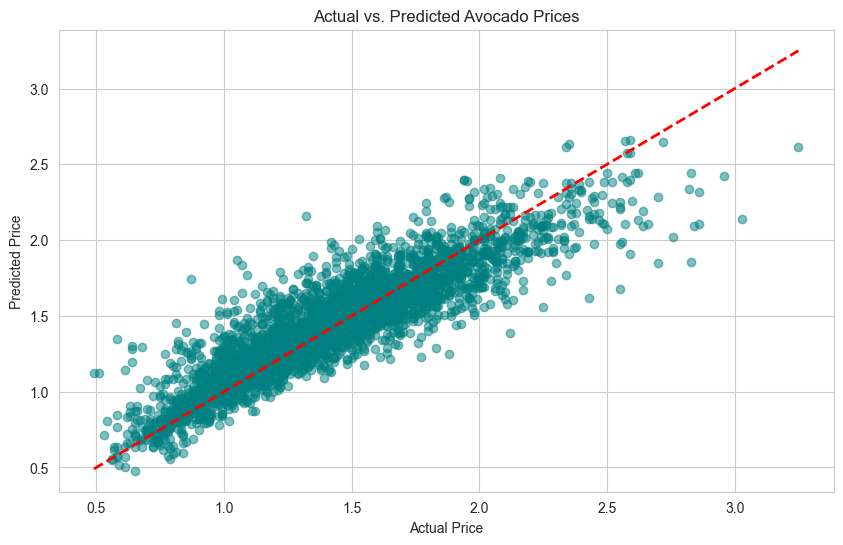

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted Avocado Prices')
plt.show()

In [32]:
# 1. Get the best hyperparameters found by the tuner
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# 2. Build the model with these settings
model = tuner.hypermodel.build(best_hps)

# 3. Train the model and SAVE the output to 'history'
# We use more epochs (50) to let the best model fully converge
history = model.fit(X_train, y_train, epochs=50, validation_split=0.2)

Epoch 1/50
365/365 [==============================] - 2s 3ms/step - loss: 0.1763 - mae: 0.2802 - val_loss: 0.0650 - val_mae: 0.1892
Epoch 2/50
365/365 [==============================] - 1s 2ms/step - loss: 0.0568 - mae: 0.1764 - val_loss: 0.0516 - val_mae: 0.1704
Epoch 3/50
365/365 [==============================] - 1s 3ms/step - loss: 0.0491 - mae: 0.1618 - val_loss: 0.0584 - val_mae: 0.1675
Epoch 4/50
365/365 [==============================] - 1s 2ms/step - loss: 0.0446 - mae: 0.1530 - val_loss: 0.0428 - val_mae: 0.1523
Epoch 5/50
365/365 [==============================] - 1s 3ms/step - loss: 0.0389 - mae: 0.1438 - val_loss: 0.0401 - val_mae: 0.1463
Epoch 6/50
365/365 [==============================] - 1s 3ms/step - loss: 0.0380 - mae: 0.1404 - val_loss: 0.0413 - val_mae: 0.1432
Epoch 7/50
365/365 [==============================] - 1s 2ms/step - loss: 0.0378 - mae: 0.1371 - val_loss: 0.0362 - val_mae: 0.1366
Epoch 8/50
365/365 [==============================] - 1s 3ms/step - loss: 0.

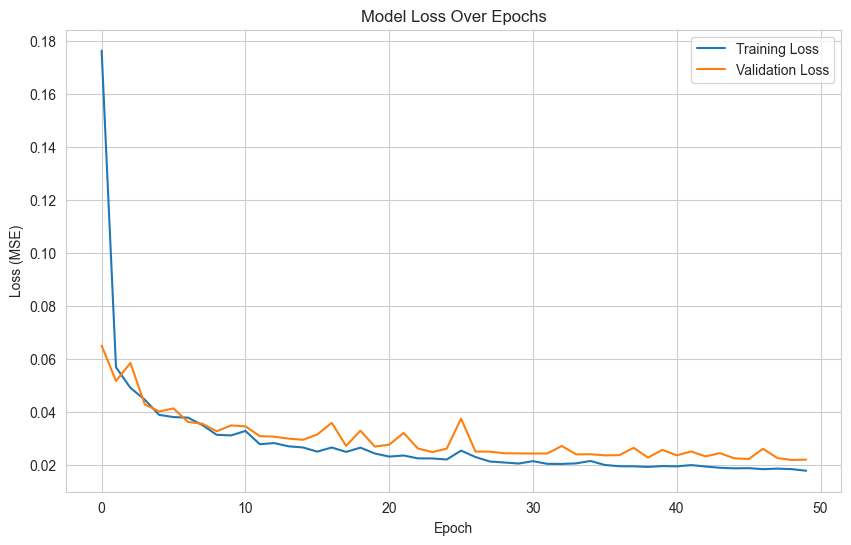

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.show()